# kmeans_cluster_practice

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1 - Define the problem

# Step 2 - Collect and Prepare Data

In [2]:
udf=pd.read_csv('Universities.csv',index_col='Univ')
udf.head()

,SAT,Top10,Accept,SFRatio,Expenses,GradRate
Univ,,,,,,
Brown,1310,89,22,13,22704,94
CalTech,1415,100,25,6,63575,81
CMU,1260,62,59,9,25026,72
Columbia,1310,76,24,12,31510,88
Cornell,1280,83,33,13,21864,90


In [3]:
udf.shape

(25, 6)

# Step 3 - Split the Data

- Here it is not required as data set is small

# Step 4 – Scale the dataset – if required

In [4]:
from sklearn.preprocessing import StandardScaler

In [5]:
scaler=StandardScaler()
scaled_data=scaler.fit_transform(udf)
scaled_data

array([[ 0.41028362,  0.6575195 , -0.88986682,  0.07026045, -0.33141256,
         0.82030265],
       [ 1.39925928,  1.23521235, -0.73465749, -1.68625071,  2.56038138,
        -0.64452351],
       [-0.06065717, -0.76045386,  1.02438157, -0.93346022, -0.16712136,
        -1.65863393],
       [ 0.41028362, -0.02520842, -0.78639393, -0.18066972,  0.29164871,
         0.14422904],
       [ 0.12771914,  0.34241431, -0.32076595,  0.07026045, -0.39084607,
         0.36958691],
       [ 0.69284809,  0.6575195 , -0.83813038, -0.68253005,  0.33778044,
         0.93298158],
       [ 0.4573777 ,  0.71003703, -0.47597528, -0.18066972,  0.29695528,
         0.93298158],
       [-0.10775125, -0.13024348, -0.78639393, -0.18066972, -0.51381683,
         0.59494478],
       [ 1.25797704,  0.76255456, -1.30375836, -0.43159988,  0.85874344,
         1.15833946],
       [ 0.36318954, -0.07772595,  0.24833493, -1.43532055,  2.21481798,
         0.0315501 ],
       [ 1.06960072,  0.92010716, -0.47597528, -0.

In [6]:
#scaled_data

# Step 5 - Choose the Algorithm and Build the model

In [7]:
from sklearn.cluster import KMeans

In [8]:
model=KMeans(n_clusters=3)
model.fit(scaled_data)

C:\Users\Dell\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Dell\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Dell\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Dell\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^

KMeans(n_clusters=3)

# Step 6 -Train the Model

- Alreadsy done by passsing direct dataset

# Step 7 - Evaluate the Model

In [9]:
model.labels_

array([0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 0], dtype=int32)

In [10]:
# lut us atatch ouptut to dataset so we can idenfy the groups
udf['Labels']=model.labels_

In [11]:
model.inertia_ # WCSS - The inertia_ attribute is specific to KMeans clustering.

49.69054164653249

In [12]:
udf

,SAT,Top10,Accept,SFRatio,Expenses,GradRate,Labels
Univ,,,,,,,
Brown,1310,89,22,13,22704,94,0
CalTech,1415,100,25,6,63575,81,2
CMU,1260,62,59,9,25026,72,0
Columbia,1310,76,24,12,31510,88,0
Cornell,1280,83,33,13,21864,90,0
Dartmouth,1340,89,23,10,32162,95,0
Duke,1315,90,30,12,31585,95,0
Georgetown,1255,74,24,12,20126,92,0
Harvard,1400,91,14,11,39525,97,0


## Step 7.1 - Evaluate the Model by using silhouette_score

In [26]:
from sklearn.metrics import silhouette_score

In [28]:
silhouette_score(udf, model.labels_)

np.float64(0.39393679043836066)

In [13]:
# group  by labels

In [14]:
grp=udf.groupby('Labels')
grp.agg('mean')

,SAT,Top10,Accept,SFRatio,Expenses,GradRate
Labels,,,,,,
0,1306.388889,84.277778,31.277778,11.777778,28175.111111,90.444444
1,1085.200000,44.000000,69.600000,18.600000,11056.400000,74.400000
2,1360.000000,87.500000,34.500000,6.500000,61133.000000,84.000000


In [15]:
- Need to understand how it has made / on what basis it has made grouping. That we will do analysis by using above mean

SyntaxError: invalid syntax (1753594171.py, line 1)

In [16]:
# how we can see grouping with each record.
for x,y in grp:
    print(y)
    print('-'*60)# it will print the 60 hifen(-) after each group

               SAT  Top10  Accept  SFRatio  Expenses  GradRate  Labels
Univ                                                                  
Brown         1310     89      22       13     22704        94       0
CMU           1260     62      59        9     25026        72       0
Columbia      1310     76      24       12     31510        88       0
Cornell       1280     83      33       13     21864        90       0
Dartmouth     1340     89      23       10     32162        95       0
Duke          1315     90      30       12     31585        95       0
Georgetown    1255     74      24       12     20126        92       0
Harvard       1400     91      14       11     39525        97       0
MIT           1380     94      30       10     34870        91       0
Northwestern  1260     85      39       11     28052        89       0
NotreDame     1255     81      42       13     15122        94       0
Princeton     1375     91      14        8     30220        95       0
Stanfo

In [17]:
for x,y in grp:
    print(x)
    print('-'*60)

0
------------------------------------------------------------
1
------------------------------------------------------------
2
------------------------------------------------------------


# Step 8 - Tune Hyperparameters

In [18]:
# lets build the model for 10 k values 

In [19]:
wcss=[]
for k in range(1,11):
    model1 = KMeans(n_clusters=k)
    model1.fit(scaled_data)
    wcss.append(model1.inertia_)
    

C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

In [20]:
wcss

[149.99999999999997,
 64.47316262551324,
 49.62899838558844,
 39.21403737176233,
 35.14628723120845,
 28.373863075720582,
 19.499355478028917,
 16.68938438487478,
 13.369239207472088,
 13.791777708178929]

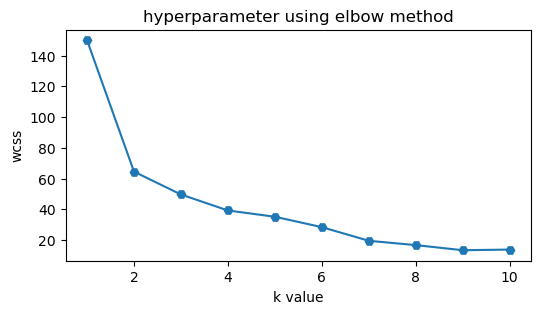

In [21]:
# lets plot
plt.figure(figsize=(6,3))
plt.plot(range(1,11),wcss,marker='H')
plt.title('hyperparameter using elbow method')
plt.xlabel('k value')
plt.ylabel('wcss')
plt.show()

In [22]:
- Acccording to aabove we can consider 4 is the best fit value for alorithm(as curve is becoming flat from this point)
- Ideally this shold be done before buliding the model

SyntaxError: invalid syntax (1640694999.py, line 1)

In [23]:
wcss_dict={}
for k in range(1,11):
    model1 = KMeans(n_clusters=k)
    model1.fit(scaled_data)
    wcss_dict.update({k:model1.inertia_})


C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

In [24]:
wcss_dict

{1: 149.99999999999997,
 2: 64.47316262551324,
 3: 44.666152784702376,
 4: 40.305859675620134,
 5: 28.96866904732409,
 6: 28.16945544647274,
 7: 19.427233353571516,
 8: 17.727270316164557,
 9: 13.733170857925709,
 10: 10.981061709811023}